# Task 4 — Anomalies & suspicious devices

Task 4 should be read against the selected Task 1 estimate, so this notebook uses **Plan C** (`estimated_total_footfall`) as the main footfall anomaly baseline and keeps **Plan B** (`footfall_plan_b`) as a comparison with HOD/consensus methods.

Two tracks:

1. **Suspicious devices** — long-tail session counts or high night activity among unflagged devices.
2. **Hourly footfall outliers** — Plan C uses per-facility z-scores on `estimated_total_footfall`; Plan B adds HOD, robust, and consensus diagnostics.

**Advanced methods** (matrix profile, STL, isolation forest, Markov journeys) run on Plan C-compatible root outputs and Plan B outputs, then compare method agreement.

| Method | Detects |
|--------|---------|
| Baseline z / HOD | Unusual level vs facility or same hour-of-day |
| Matrix profile | Local shape unlike other week segments |
| STL | Large residual after trend + daily seasonality |
| Isolation forest | Multivariate odd hours (sessions, devices, signal, footfall) |
| Markov | Rare facility-to-facility paths |
| Consensus | ≥2 methods agree on the same sensor-hour |

Run pipelines first: `python run_analysis.py` and `python plan_b/run_analysis.py`

## Baseline Task 4 (Plan C selected estimate)

In [1]:
from notebook_helpers import run_task4, plot_task4, show_task_plots

# Plan C is the delivered Task 1 estimate (`estimated_total_footfall`).
t4_c = run_task4(force_recompute=False, plan="c")
t4_c["anomaly_summary"]

{'high_session_threshold': 32.0,
 'suspicious_unflagged_devices': 87,
 'anomaly_hours_global': 22,
 'anomaly_hours_robust': 181,
 'anomaly_hours_hod': 0,
 'anomaly_hours_consensus': 22,
 'is_excluded': 0.001054046805904619,
 'is_anomaly': 0.0,
 'is_fake': 2.7129474751131542e-05,
 'flagged_any': 0.0010811762806557505}

17 plots in /Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/outputs/plots/task4
task4_advanced_agreement_hist_plan_a.png


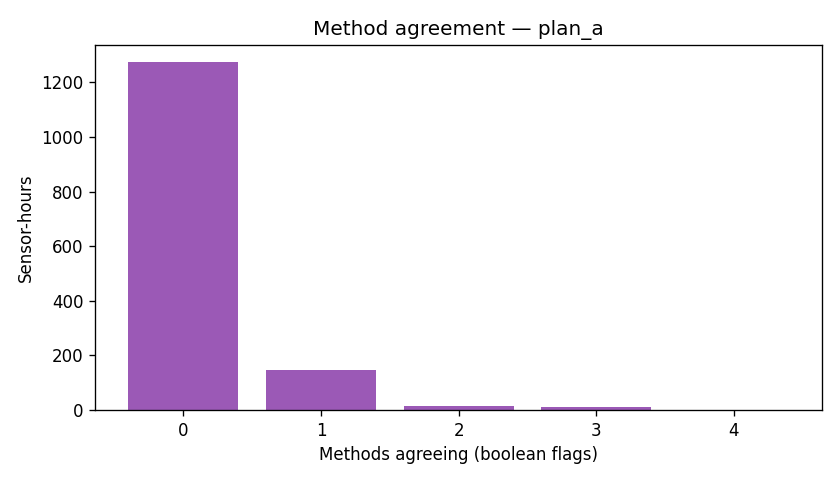

task4_advanced_agreement_hist_plan_b.png


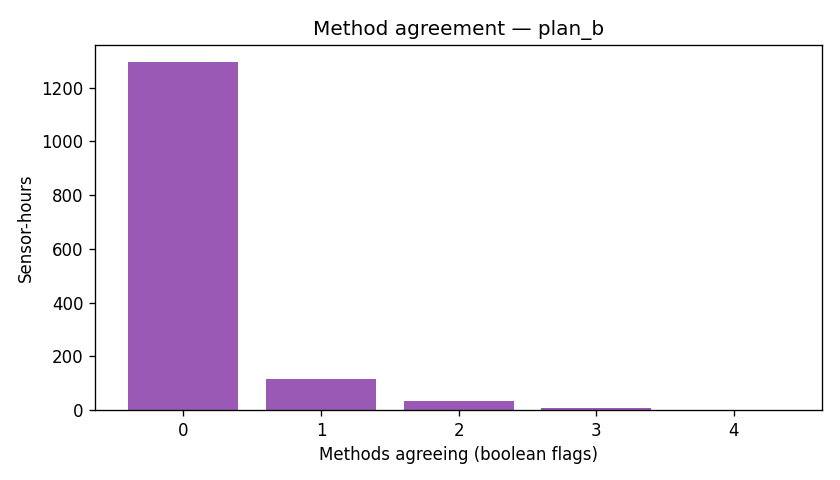

task4_advanced_method_correlation_plan_a.png


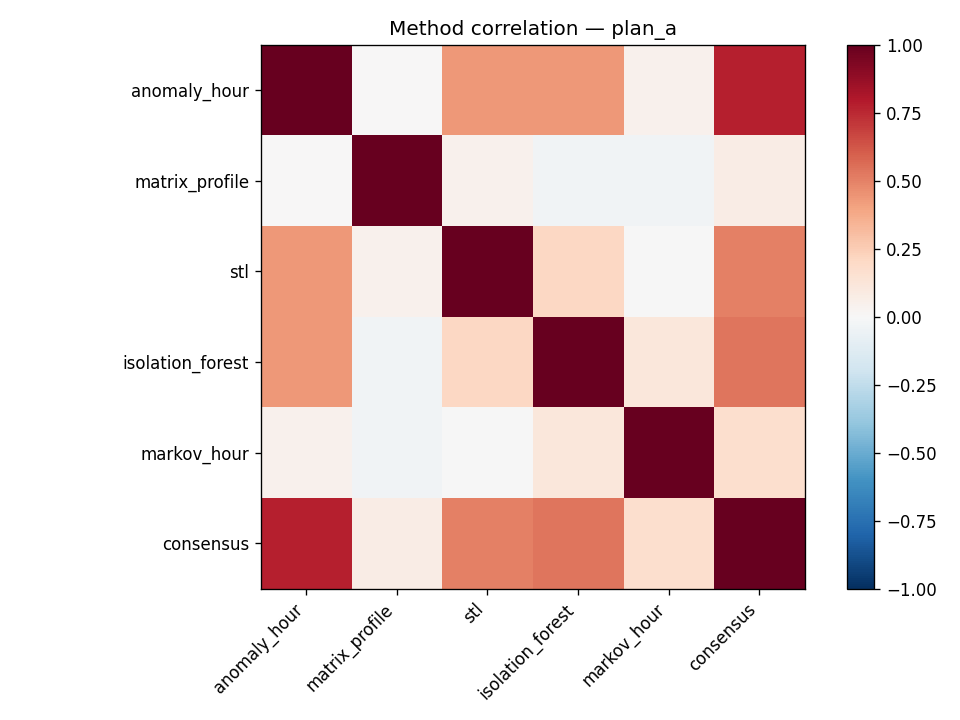

task4_advanced_method_correlation_plan_b.png


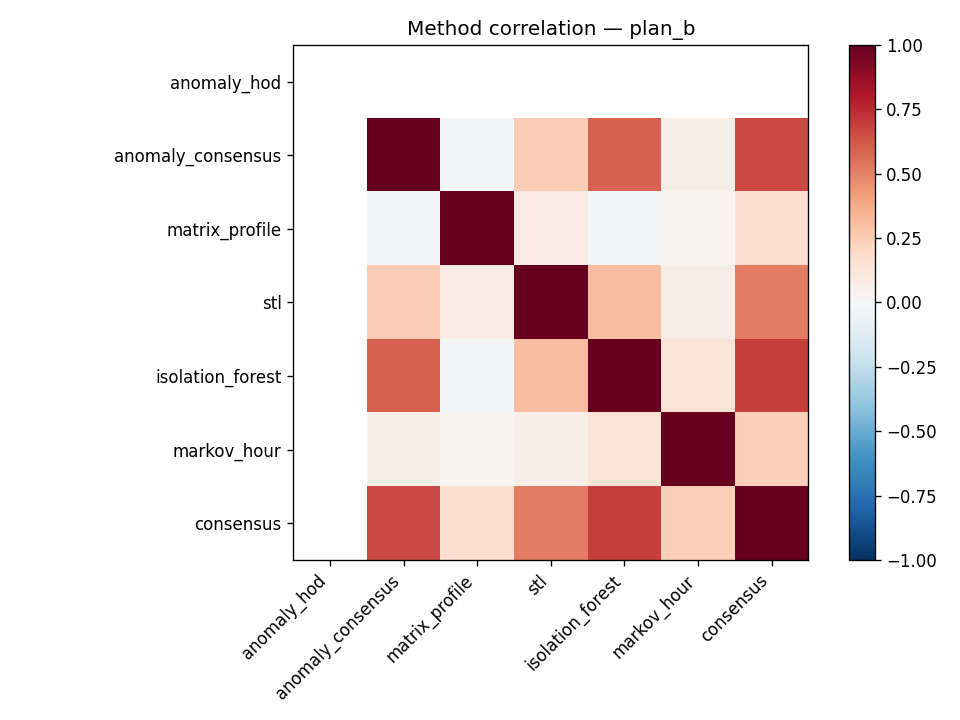

task4_advanced_method_counts_plan_a.png


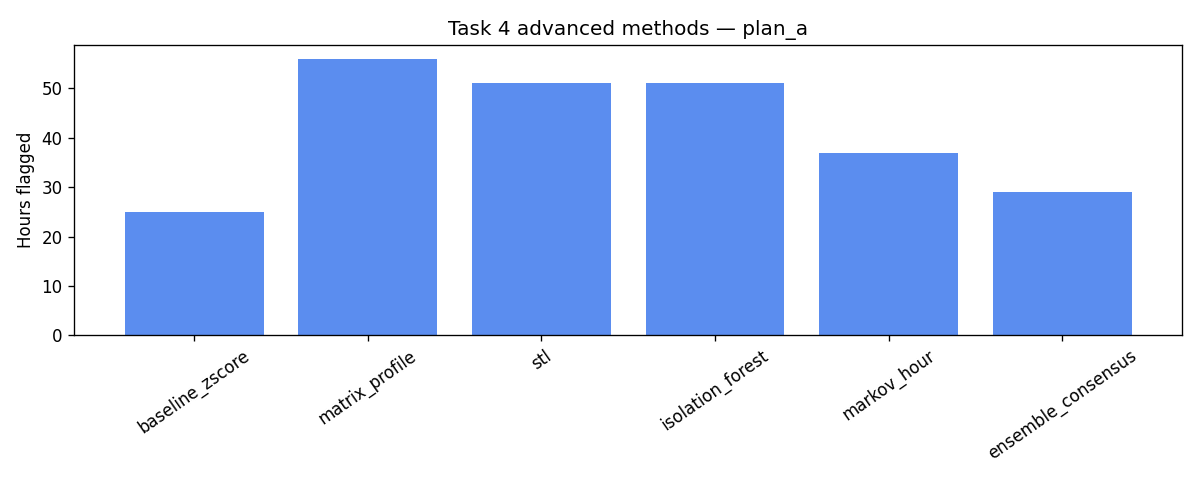

task4_advanced_method_counts_plan_a_vs_b.png


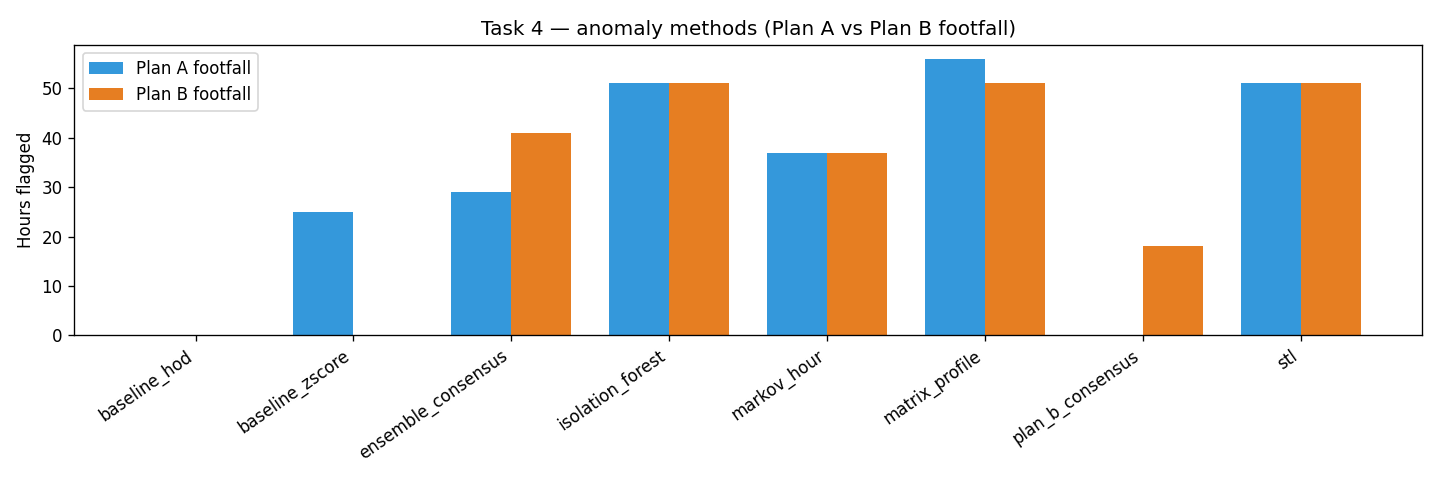

task4_advanced_method_counts_plan_b.png


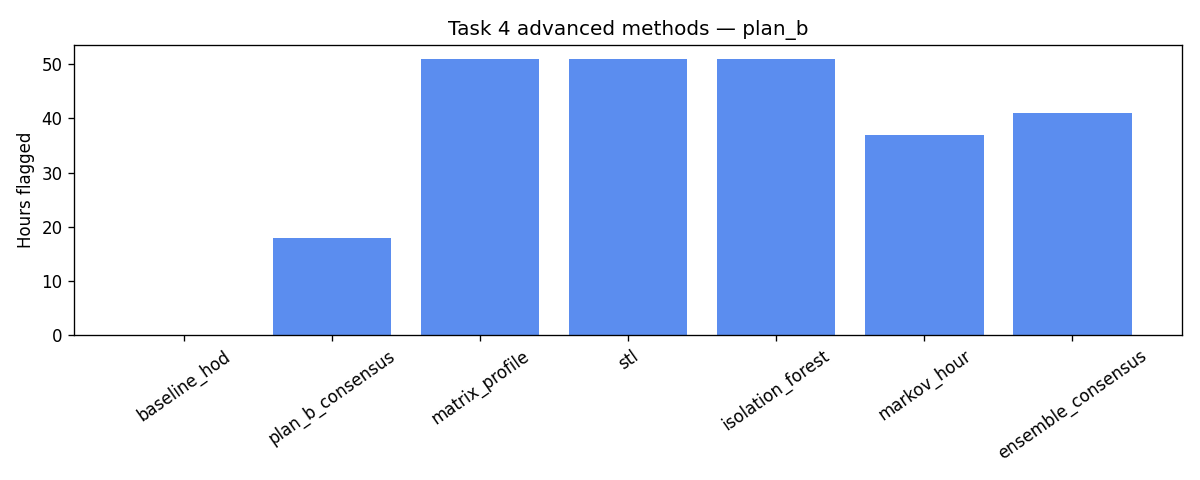

task4_advanced_top_ensemble_plan_a.png


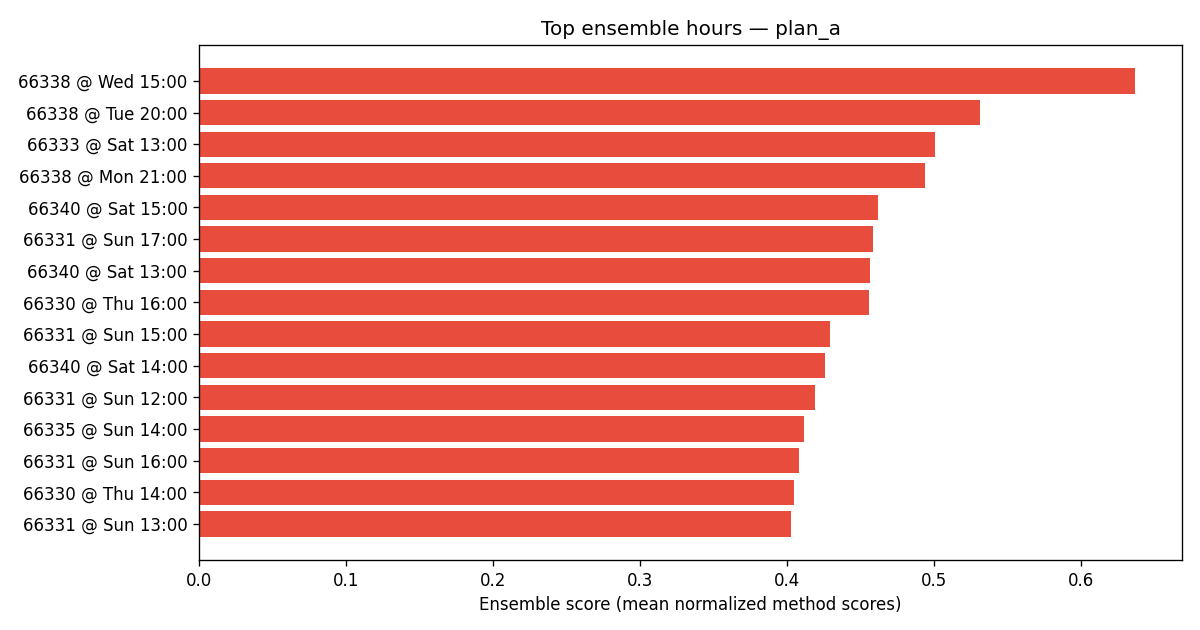

task4_advanced_top_ensemble_plan_b.png


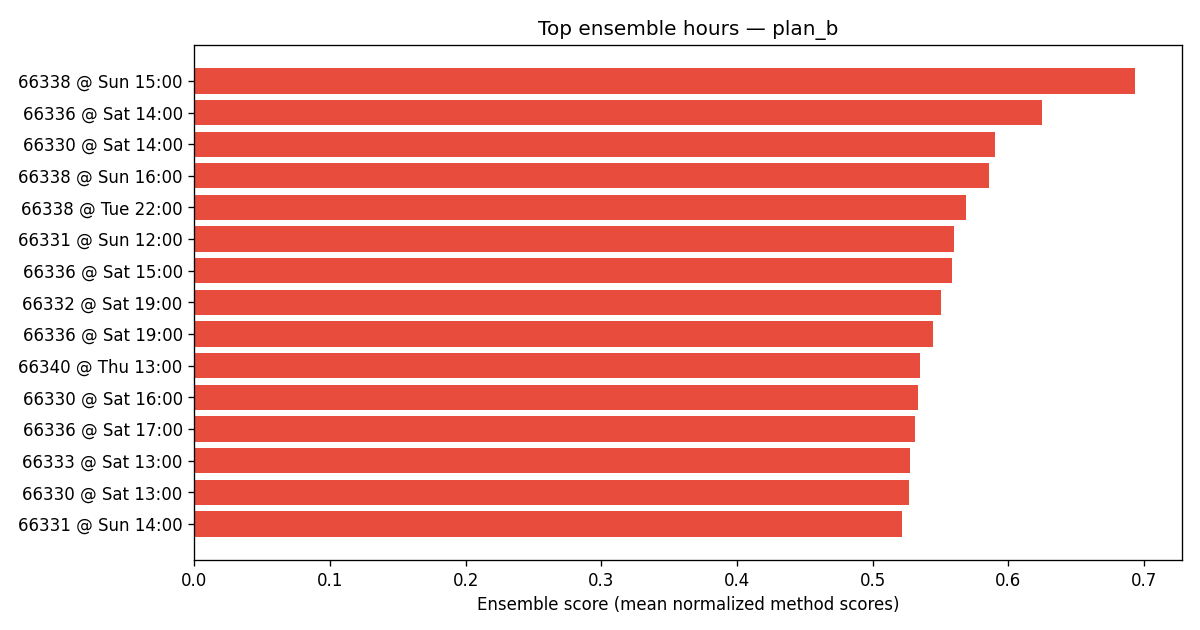

task4_anomaly_zscore_heatmap.png


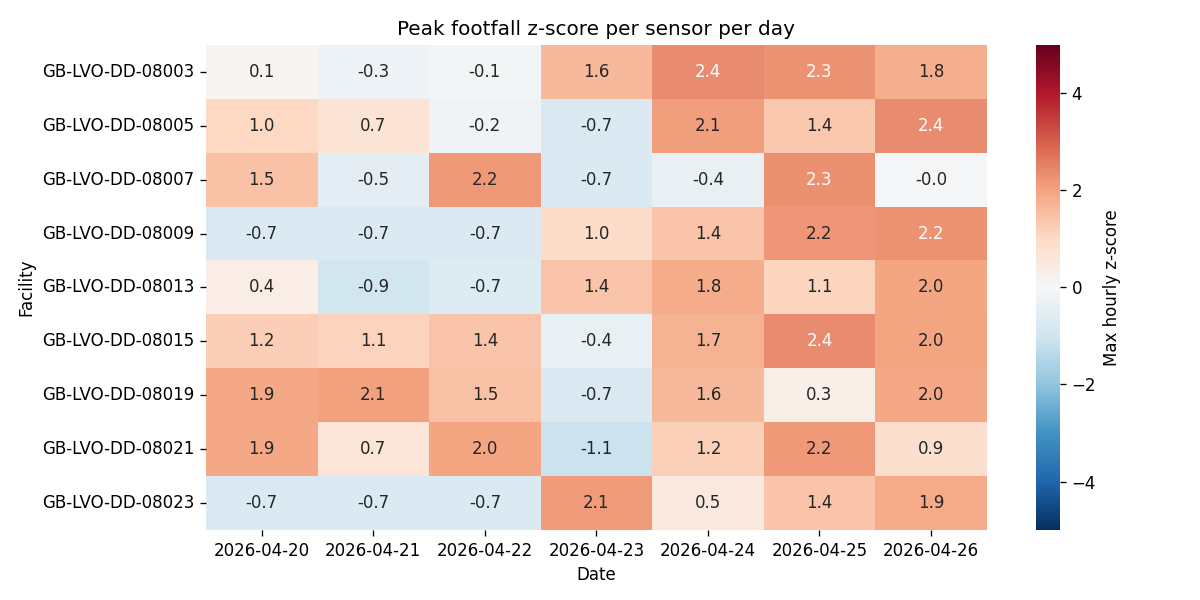

task4_device_session_distribution.png


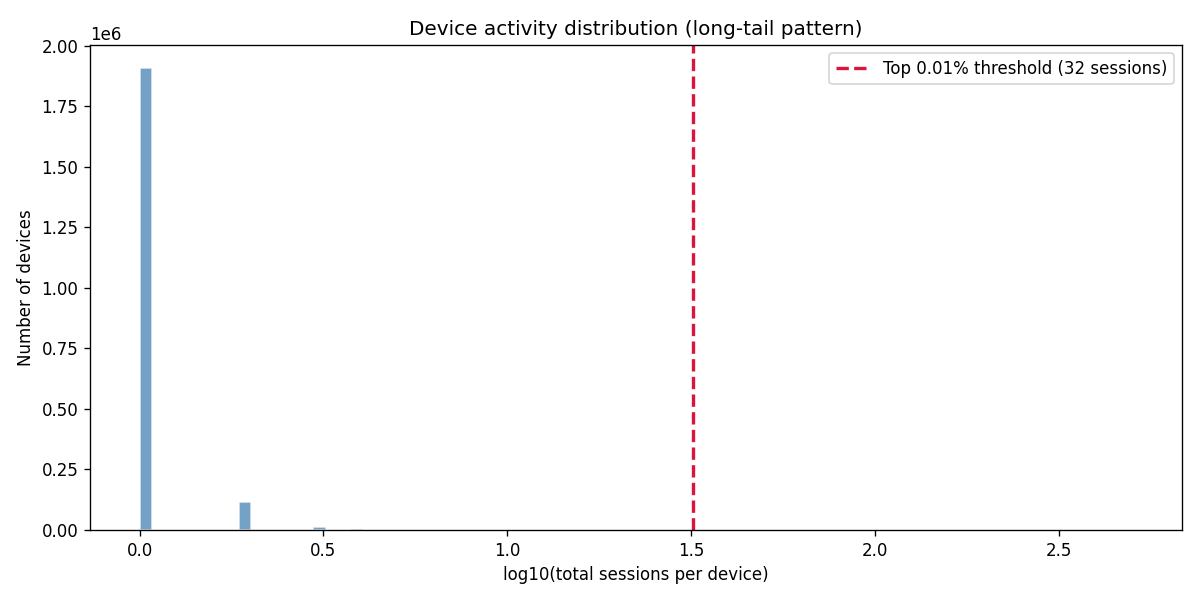

task4_facility_spread_patterns.png


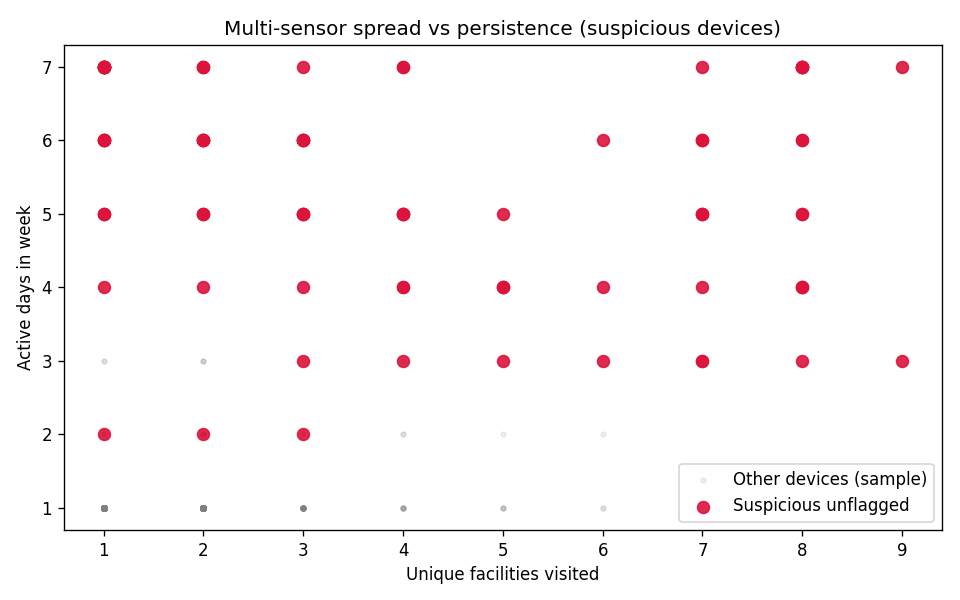

task4_flag_rates.png


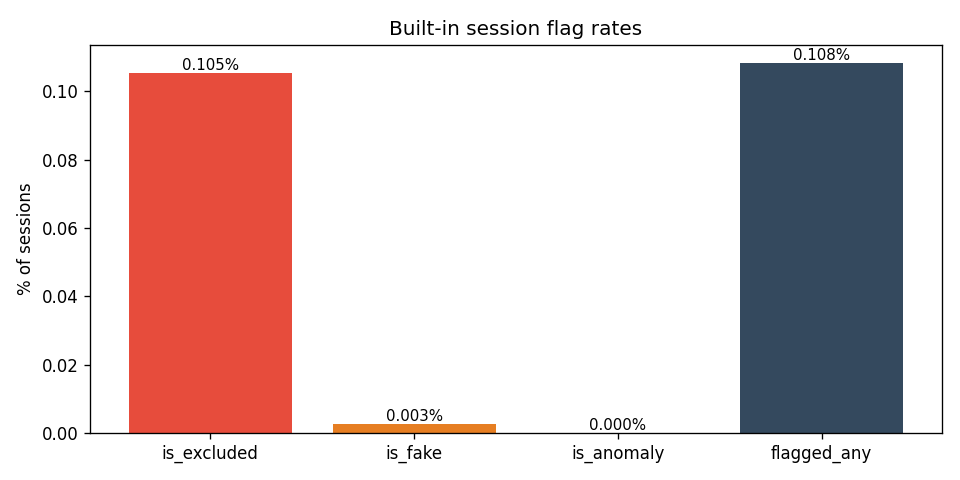

task4_hourly_footfall_anomalies.png


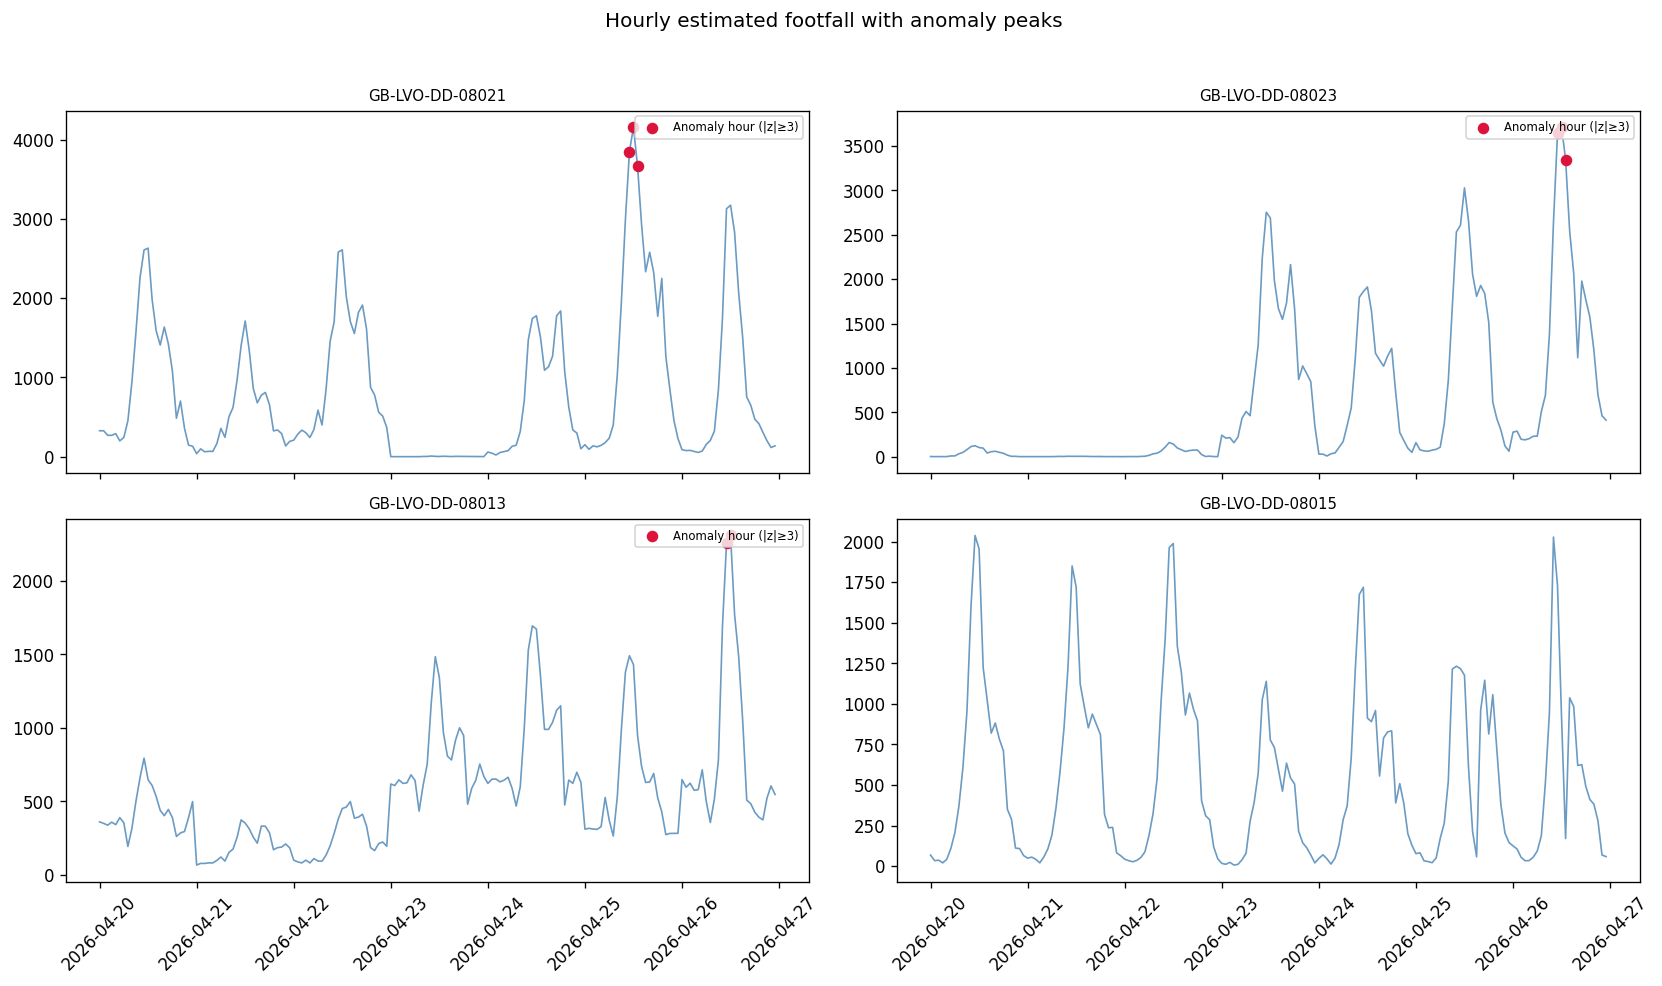

task4_sessions_by_hour_flagged.png


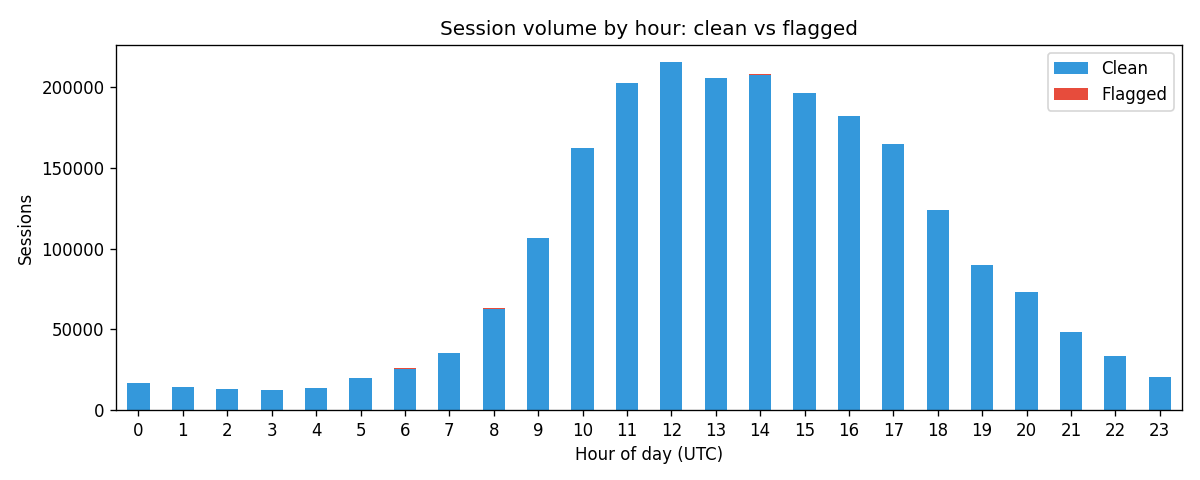

task4_suspicious_device_patterns.png


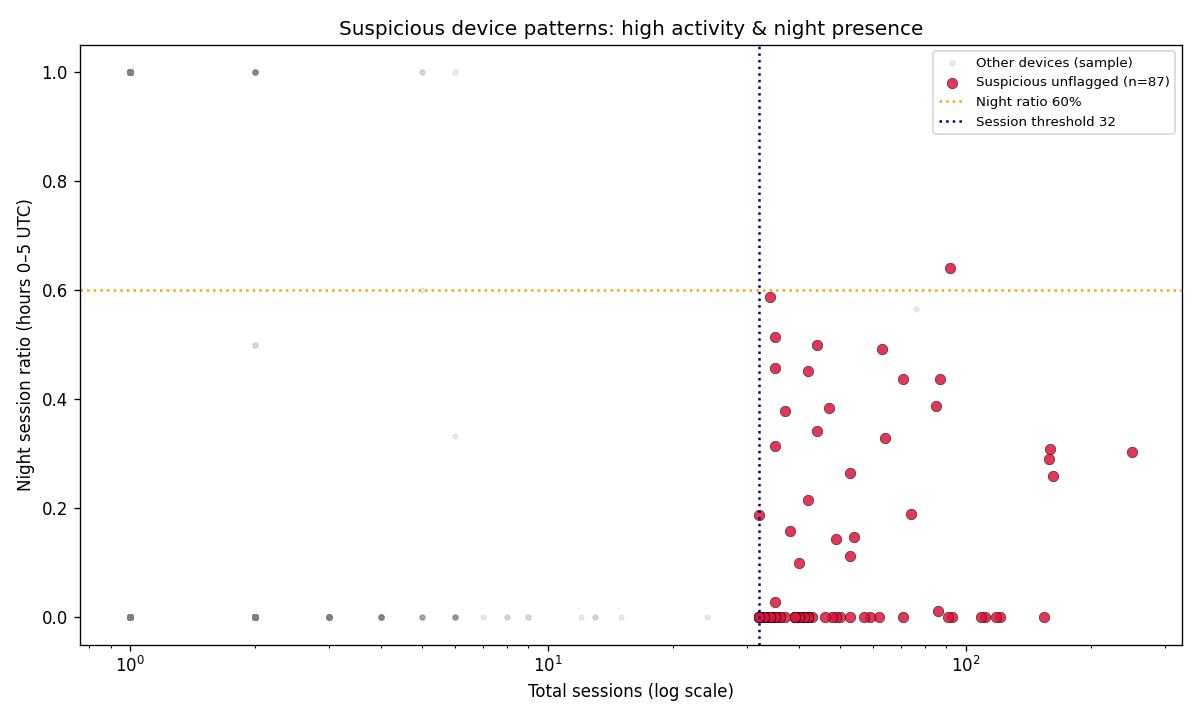

task4_top_anomaly_hours.png


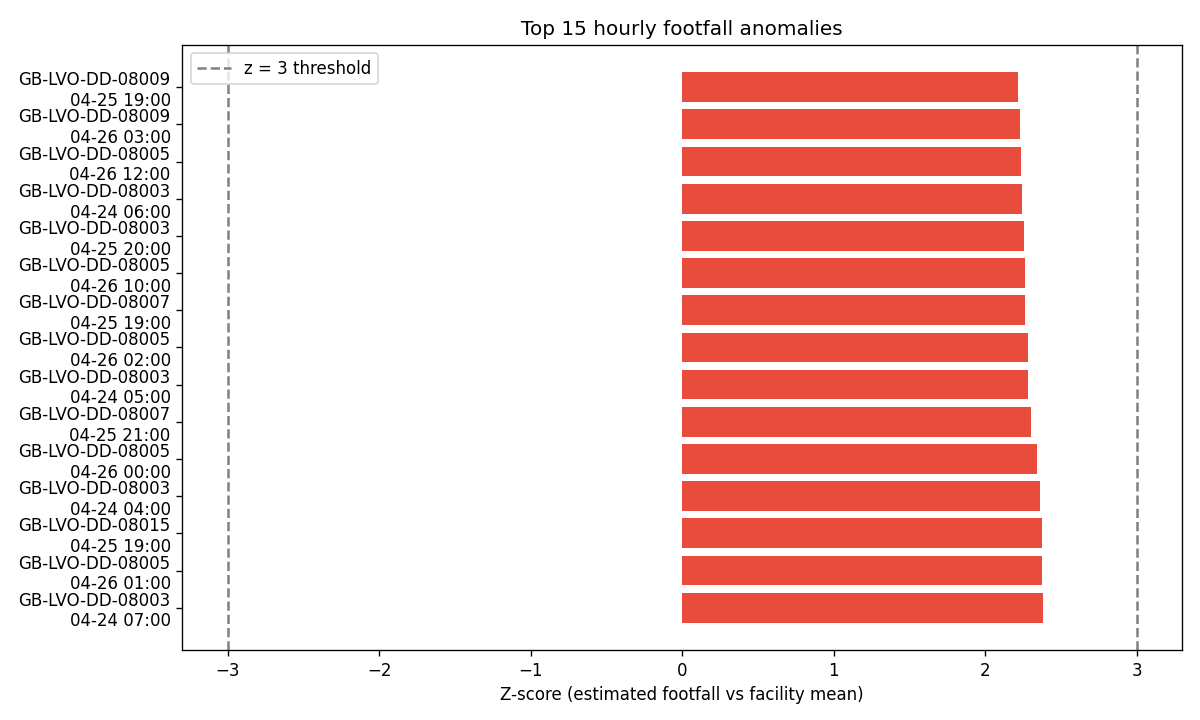

In [2]:
plot_task4(plan="c")
show_task_plots(4, plan="c")

In [3]:
cols = [c for c in t4_c["anomaly_hours"].columns if c.startswith("is_anomaly")]
t4_c["anomaly_hours"][cols].sum()

is_anomaly_global        22
is_anomaly_robust       181
is_anomaly_hod            0
is_anomaly_consensus     22
is_anomaly_stl          361
dtype: int64

## Advanced methods — Plan C and Plan B footfall

Compares matrix profile, STL, isolation forest, and Markov journeys against baseline z-scores. The Plan C-compatible advanced output is stored with the legacy filename `task4_anomaly_method_comparison_plan_a.csv` because it uses the root Task 1 output column `estimated_total_footfall`.

In [4]:
from notebook_helpers import run_task4_advanced, plot_task4_advanced, show_task_plots

adv = run_task4_advanced(force_recompute=False, plan="both")
# plan_a key is the legacy storage name for the root/Plan C-compatible footfall column.
adv["plan_a"]["comparison"].head(10)

/Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/src/task4_advanced.py:455: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison[c] = comparison[c].fillna(False).astype(bool)
/Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/src/task4_advanced.py:455: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison[c] = comparison[c].fillna(False).astype(bool)


,facility_num,hour_start,estimated_total_footfall,plan_name,footfall_col,zscore,is_anomaly_hour,matrix_profile_score,is_matrix_profile_anomaly,stl_score,...,is_markov_hour_anomaly,zscore_score,zscore_norm,matrix_profile_norm,stl_norm,isolation_forest_norm,markov_norm,ensemble_score,method_agreement_count,is_consensus_anomaly
1309,66342,2026-04-21 02:00:00+00:00,0.00,plan_a,estimated_total_footfall,-3.510711,True,3.562230,False,12.306966,...,False,3.510711,1.000000,0.404913,0.566881,0.568514,0.000000,0.508061,3,True
1202,66340,2026-04-23 14:00:00+00:00,365.52,plan_a,estimated_total_footfall,-1.520206,False,8.739502,True,10.042756,...,False,1.520206,0.432826,0.993404,0.462587,0.283408,0.338918,0.502229,1,False
533,66333,2026-04-21 05:00:00+00:00,0.00,plan_a,estimated_total_footfall,-2.744820,False,2.882397,True,21.657287,...,False,2.744820,0.781767,0.327637,0.997573,0.395024,0.000000,0.500400,2,True
529,66333,2026-04-21 01:00:00+00:00,0.00,plan_a,estimated_total_footfall,-2.744820,False,1.685906,False,20.782311,...,False,2.744820,0.781767,0.191634,0.957270,0.566871,0.000000,0.499508,2,True
1308,66342,2026-04-21 00:00:00+00:00,0.00,plan_a,estimated_total_footfall,-3.510711,True,3.239761,False,13.280359,...,False,3.510711,1.000000,0.368258,0.611717,0.516847,0.000000,0.499364,2,True
556,66333,2026-04-22 04:00:00+00:00,0.00,plan_a,estimated_total_footfall,-2.744820,False,2.384159,False,21.709976,...,False,2.744820,0.781767,0.271003,1.000000,0.416046,0.000000,0.493763,1,False
1203,66340,2026-04-23 15:00:00+00:00,342.79,plan_a,estimated_total_footfall,-1.730352,False,8.797527,True,11.696382,...,False,1.730352,0.492705,1.000000,0.538756,0.166791,0.222562,0.484163,2,True
134,66330,2026-04-25 14:00:00+00:00,633.61,plan_a,estimated_total_footfall,1.459697,False,5.643589,False,0.287594,...,False,1.459697,0.415585,0.641497,0.013247,0.797411,0.513925,0.476333,1,False
531,66333,2026-04-21 03:00:00+00:00,0.00,plan_a,estimated_total_footfall,-2.744820,False,2.568631,False,19.189571,...,False,2.744820,0.781767,0.291972,0.883906,0.401167,0.000000,0.471762,1,False
1198,66340,2026-04-23 10:00:00+00:00,372.57,plan_a,estimated_total_footfall,-1.455027,False,8.763252,True,7.940969,...,False,1.455027,0.414254,0.996104,0.365775,0.197820,0.383813,0.471553,1,False


In [5]:
adv["plan_b"]["summary"]

{'plan_name': 'plan_b',
 'footfall_col': 'footfall_plan_b',
 'baseline_zscore_col': 'zscore_hod_baseline',
 'baseline_flag_col': 'is_anomaly_hod',
 'matrix_profile_anomaly_hours': 51,
 'stl_anomaly_hours': 51,
 'isolation_forest_anomaly_hours': 51,
 'markov_journey_anomalies': 3953,
 'markov_hour_anomalies': 37,
 'consensus_anomaly_hours': 39,
 'max_method_agreement_count': 4}

17 plots in /Users/zohaibsarwar/Documents/GitHub/Mall_Footfall_Data_Analysis_Allunite/outputs/plots/task4
task4_advanced_agreement_hist_plan_a.png


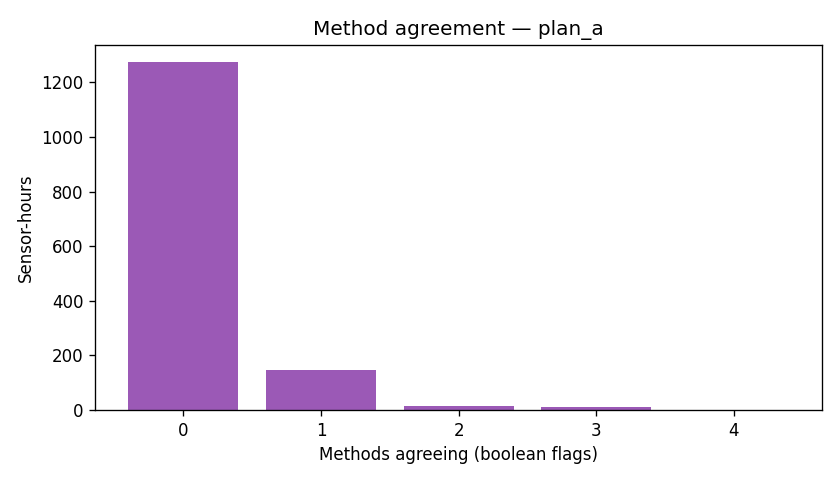

task4_advanced_agreement_hist_plan_b.png


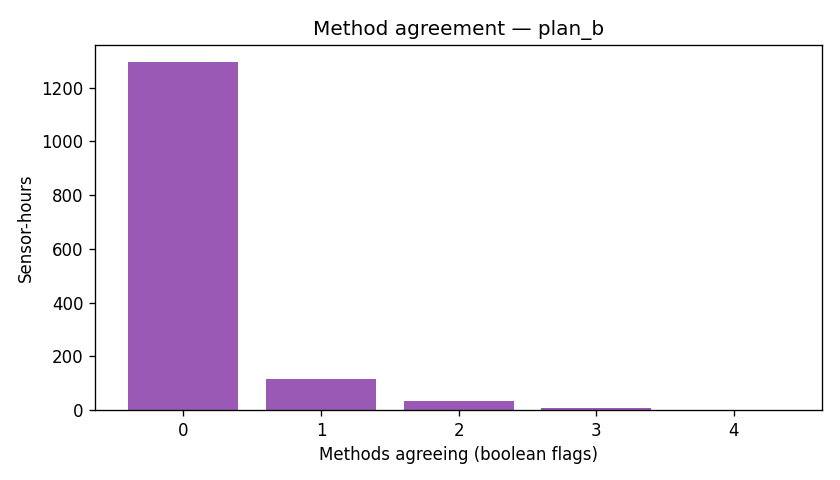

task4_advanced_method_correlation_plan_a.png


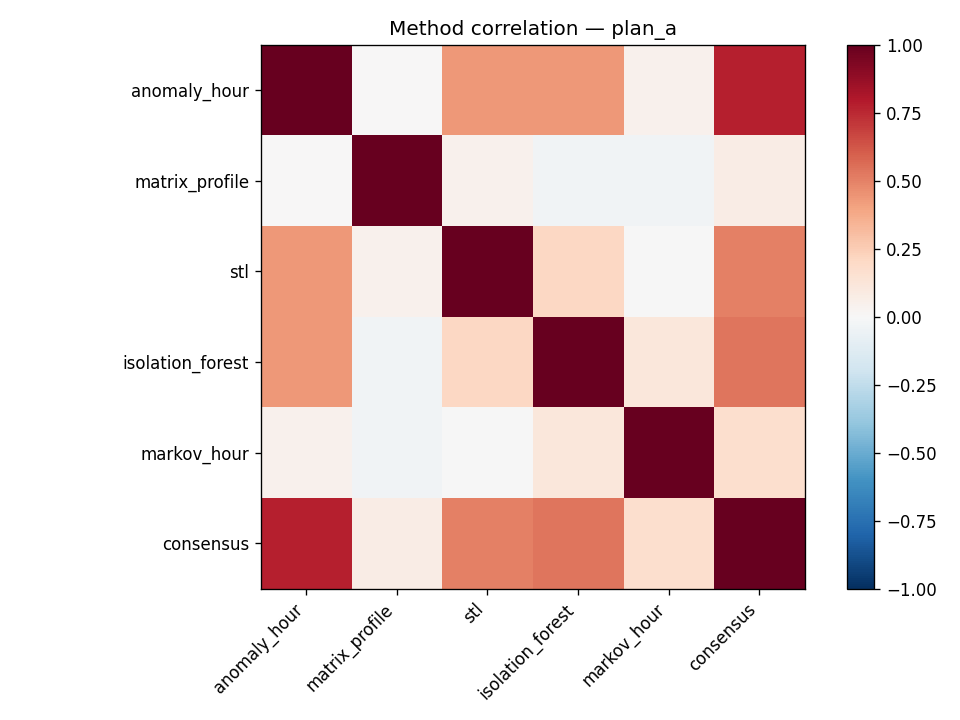

task4_advanced_method_correlation_plan_b.png


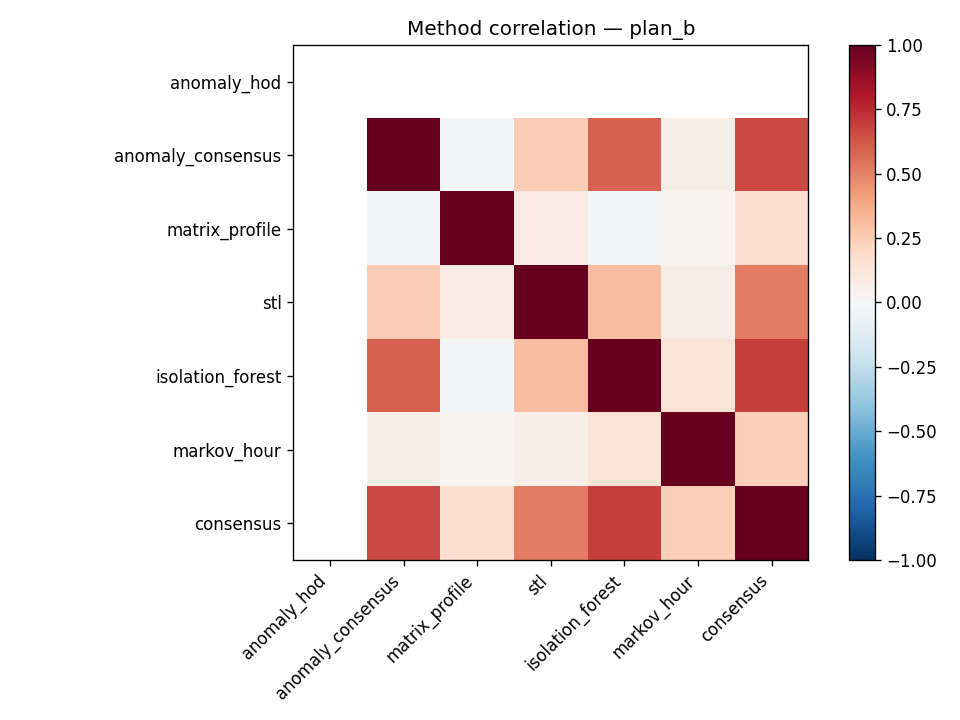

task4_advanced_method_counts_plan_a.png


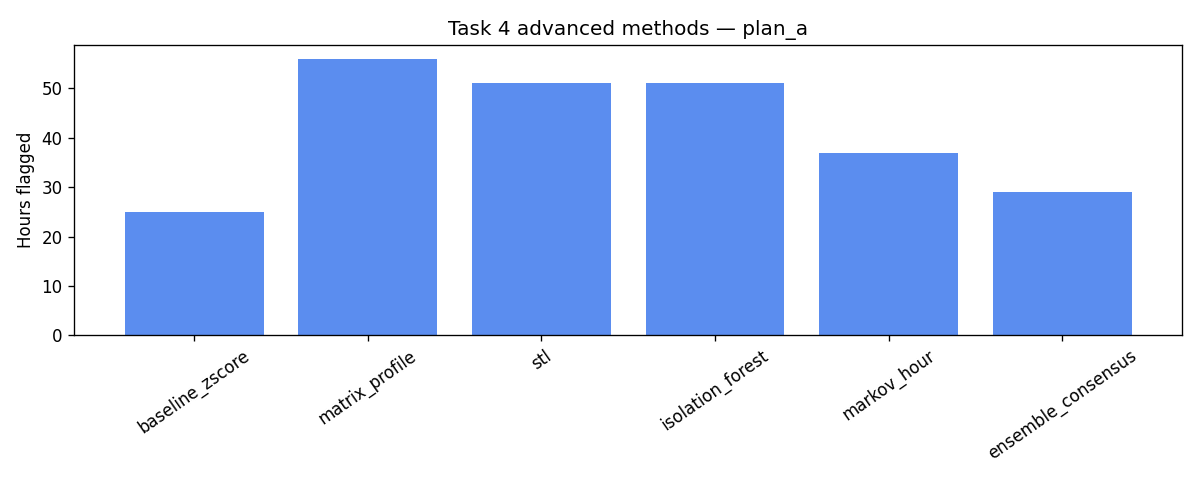

task4_advanced_method_counts_plan_a_vs_b.png


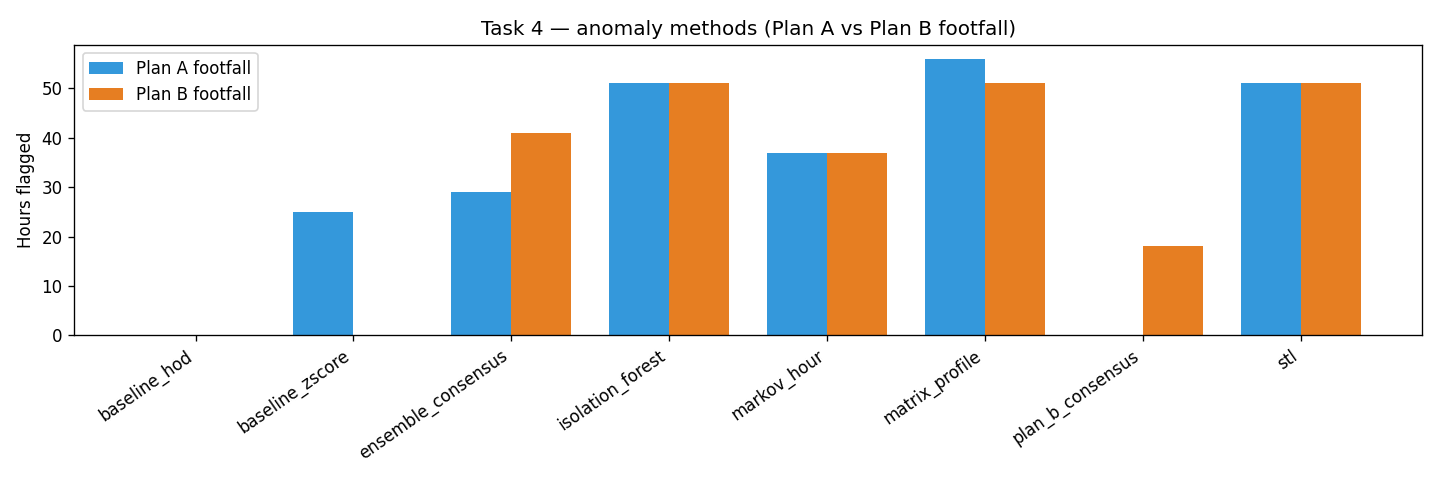

task4_advanced_method_counts_plan_b.png


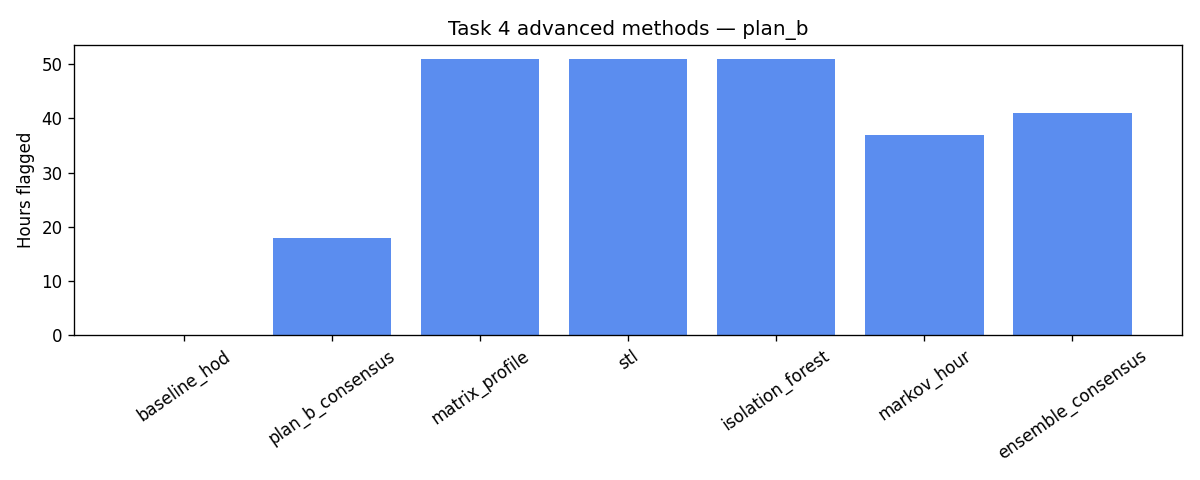

task4_advanced_top_ensemble_plan_a.png


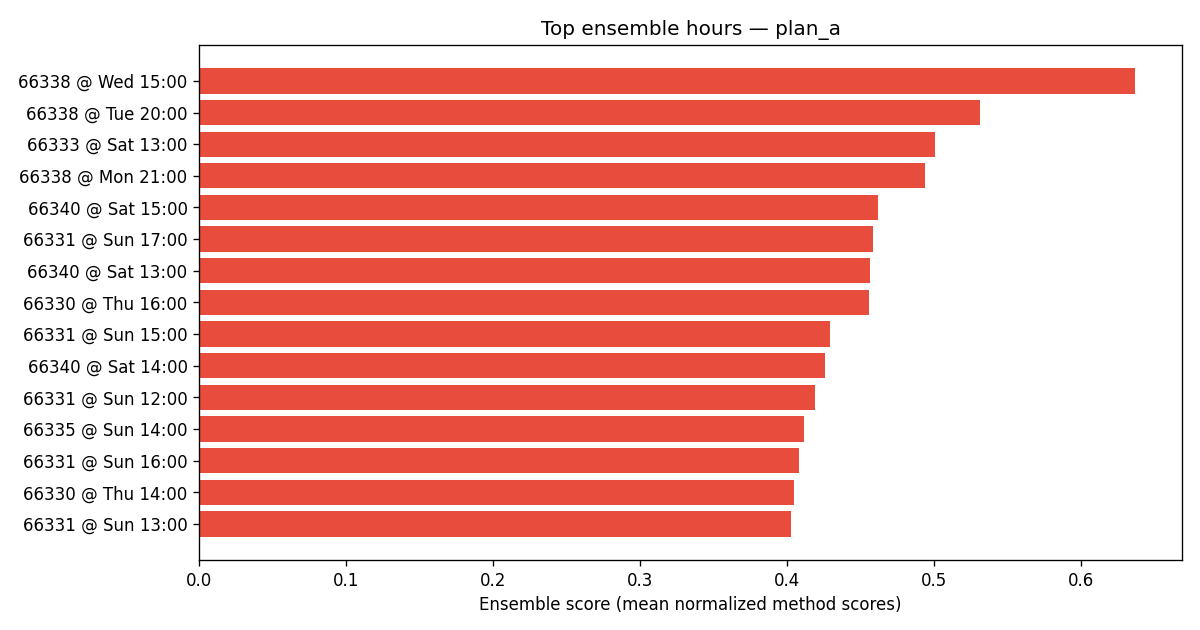

task4_advanced_top_ensemble_plan_b.png


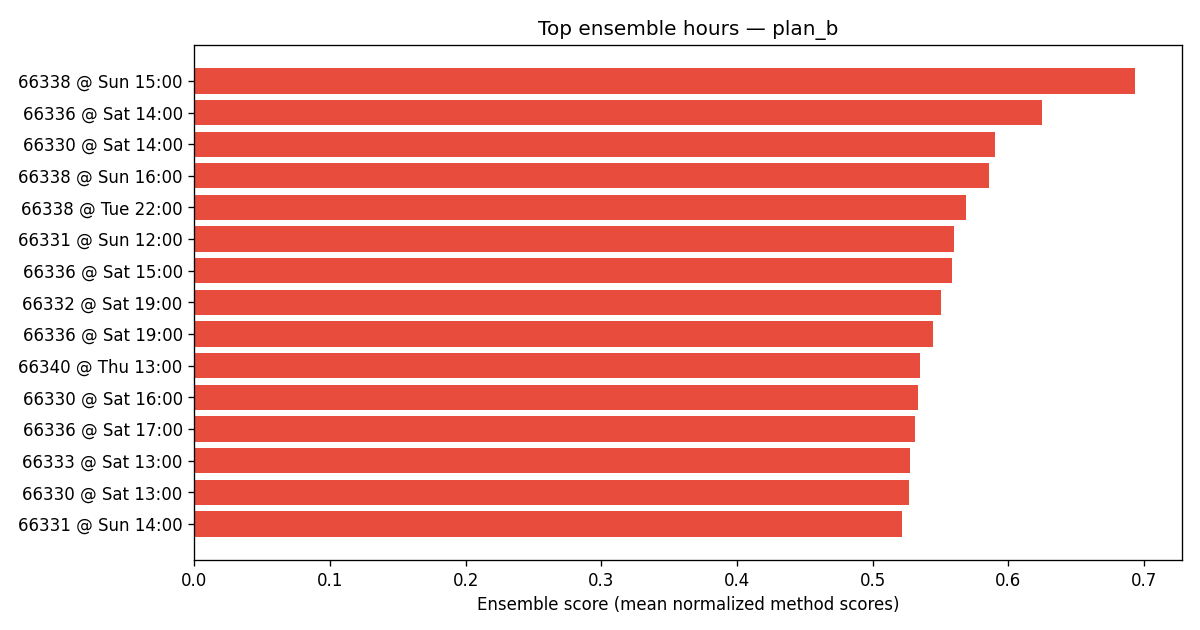

task4_anomaly_zscore_heatmap.png


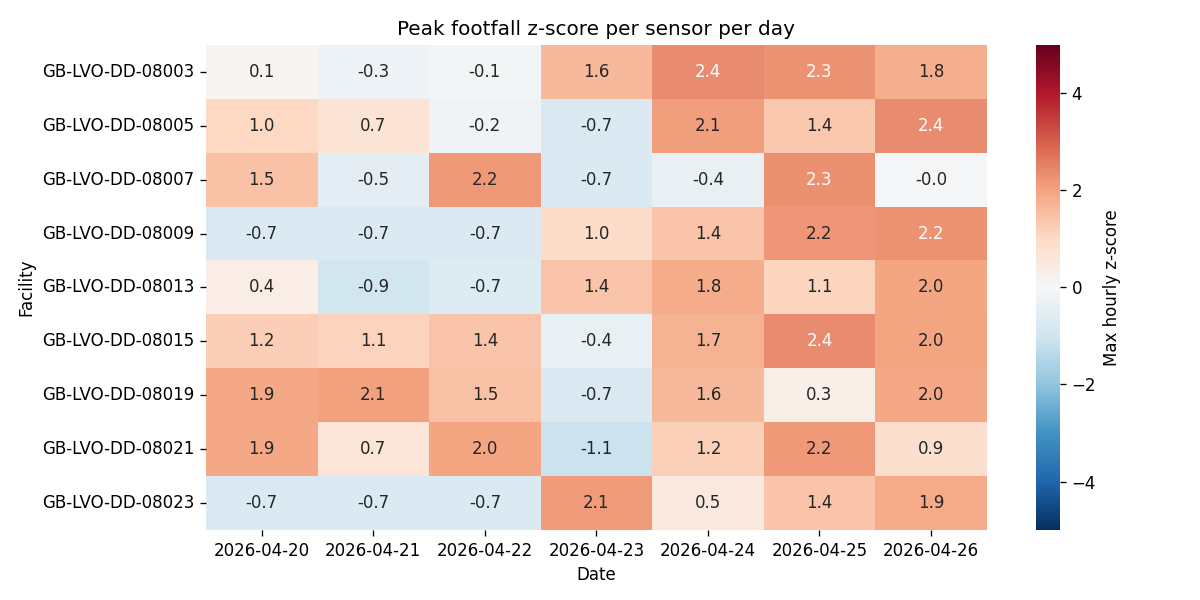

task4_device_session_distribution.png


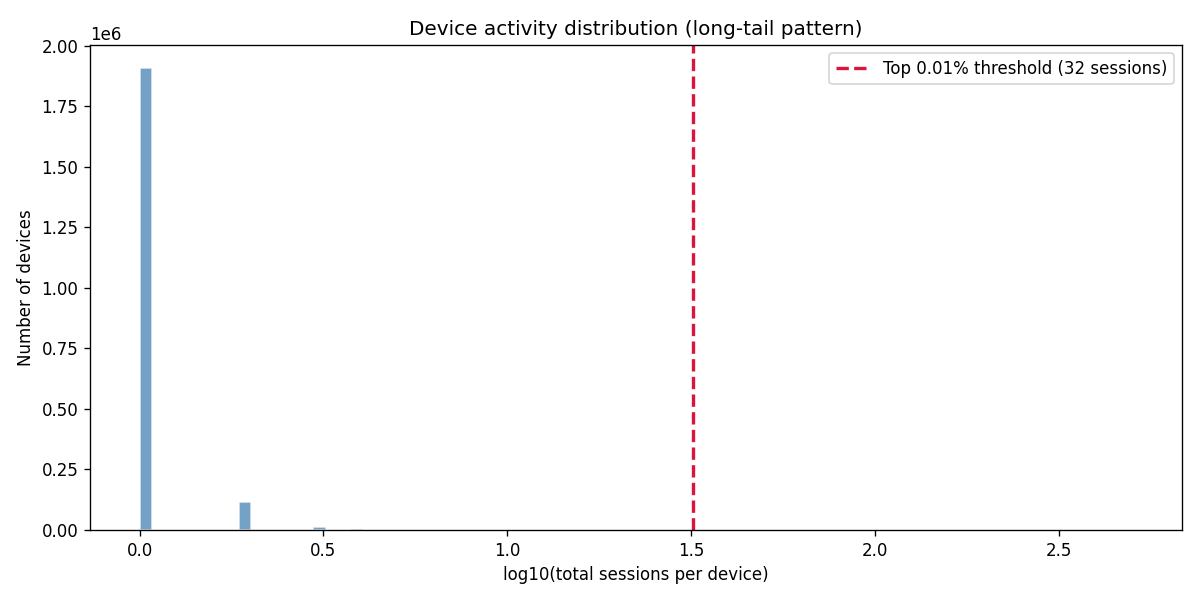

task4_facility_spread_patterns.png


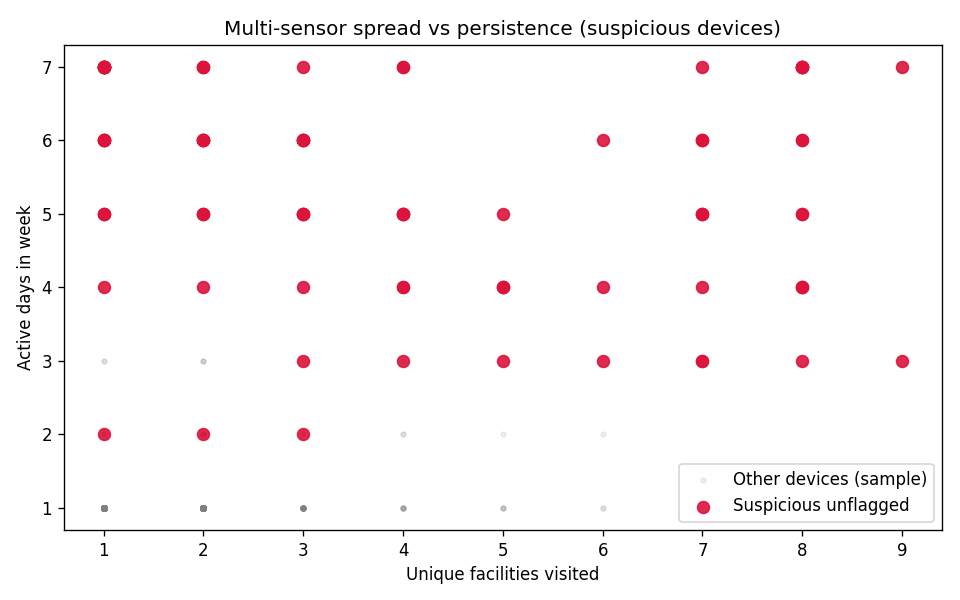

task4_flag_rates.png


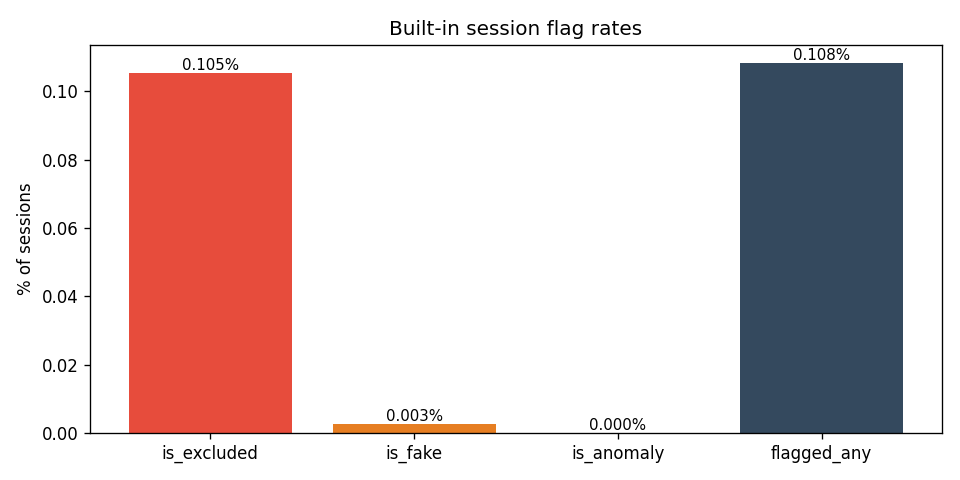

task4_hourly_footfall_anomalies.png


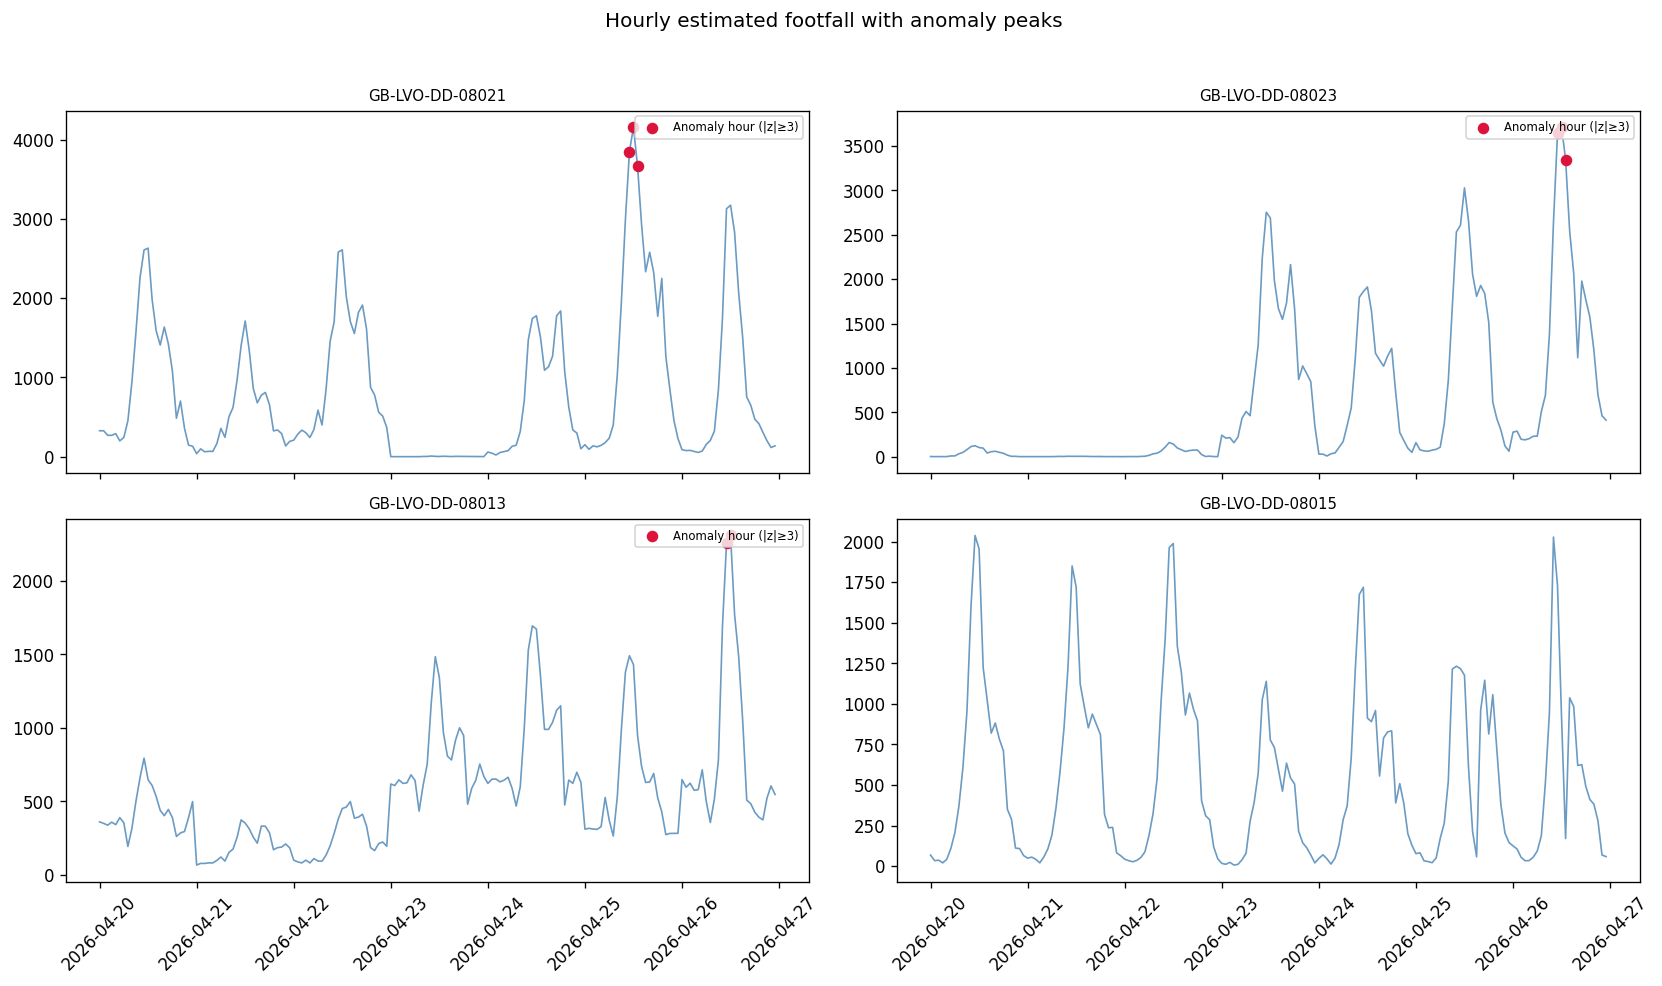

task4_sessions_by_hour_flagged.png


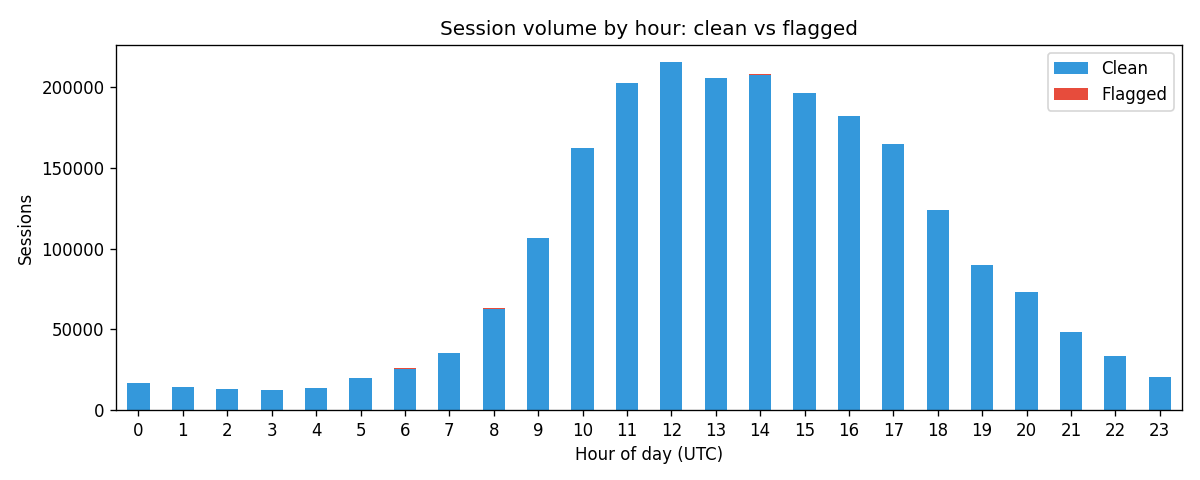

task4_suspicious_device_patterns.png


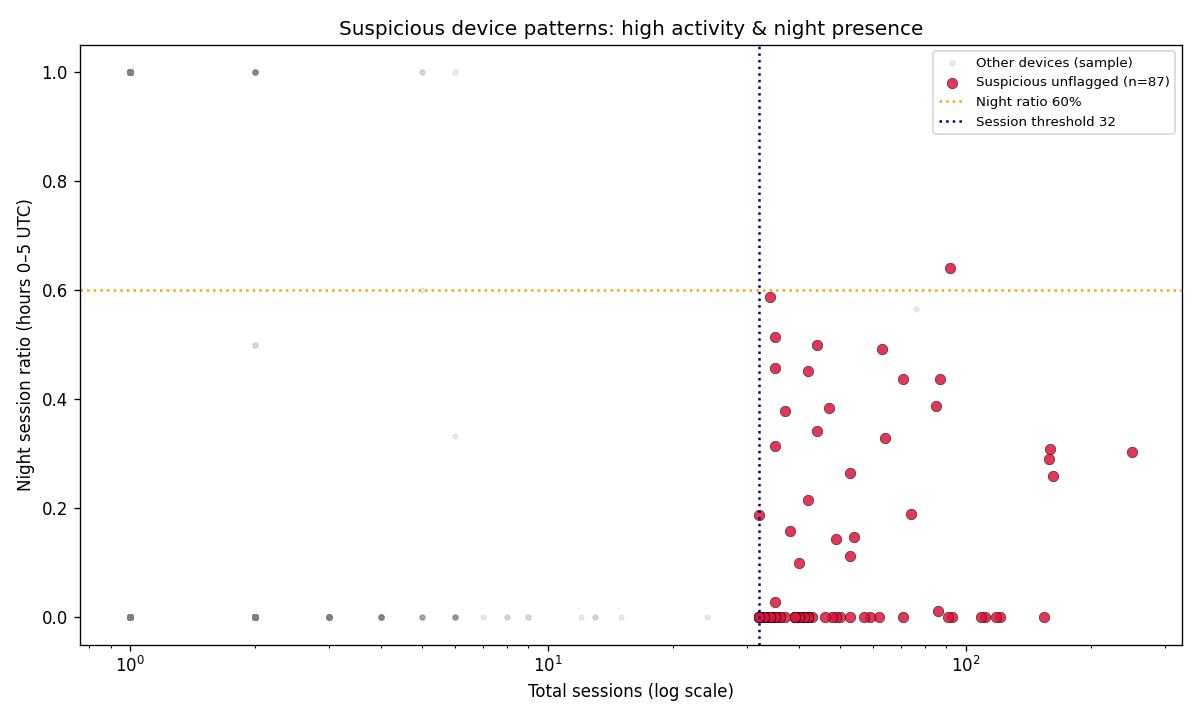

task4_top_anomaly_hours.png


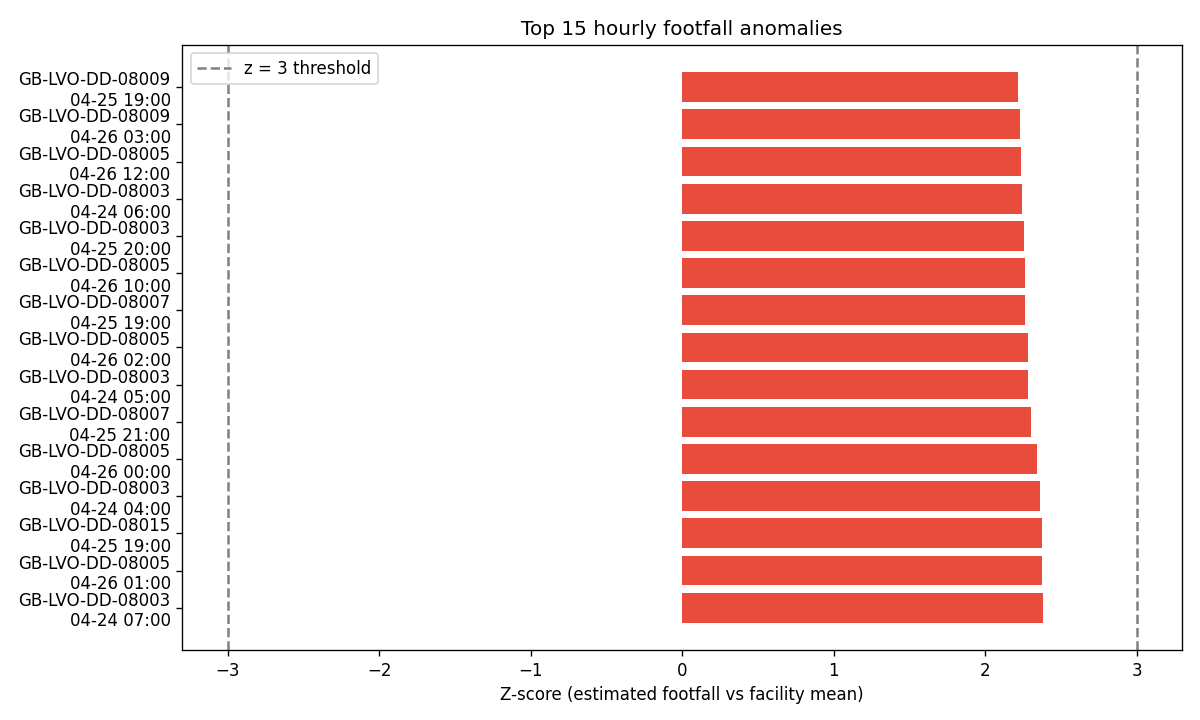

In [6]:
plot_task4_advanced(plan="both")
show_task_plots(4, plan="b")

### When to trust which method

- **Selected delivery estimate** → Plan C z-score on `estimated_total_footfall`
- **Simple HOD explainability** → Plan B HOD baseline
- **Skew / spikes** → robust z or STL residual
- **Weird hour shape** → matrix profile
- **Odd devices + signal + footfall together** → isolation forest
- **Weird walking route** → Markov journey
- **Shortlist for review** → `is_consensus_anomaly` (≥2 methods)

With only one week of data, treat STL/matrix profile as **comparative** signals—validate spikes against manual counts where possible.